In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

In [2]:
import os
os.makedirs("outputs", exist_ok=True)


In [3]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


# **PyTorch Tensors**


In [4]:
## Q1

a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

print(a.shape,a.dtype,a.device)
print(b.shape,b.dtype,b.device)
print(c.shape,c.dtype,c.device)

# These devices are on a cpu right now. Model weights and input tensors must be on the
# same device to perform computations. Mismatches causes Runtime Errors.

torch.Size([2, 3]) torch.float32 cpu
torch.Size([2, 3]) torch.float32 cpu
torch.Size([4]) torch.float32 cpu


In [5]:
#Q2

x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])
print(torch.sqrt(x), x.sum(), x.mean(), x.argmax())

#Argmax will return the score that returns the max target value. So out of 1000 values,
# it will return the highest score correlated to the max target value

tensor([1., 2., 3., 4., 5.]) tensor(55.) tensor(11.) tensor(4)


In [6]:
#Q3

a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back  = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

#Numpy are designed to run on CPU. That is why Pytorch require .cpu()

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


In [ ]:
#Q4 

t = torch.arange(24).float()
reshape = t.reshape(4, 6)
print(reshape.shape)

reshape2 = t.reshape(2, 3, 4)
print(reshape2.shape)

add_dimension = reshape.unsqueeze(0)

""" The operation that accomplishes the shape requirements of image tensor is dimension expansion. You
need to speifically add the batch dimension at index 0. You can use unsqueeze(0). The Neural networks
are designed to process data in parallel using GPUs. The neural network breaks if you give it 3 dimensions
instead of 4. 

"""

torch.Size([4, 6])
torch.Size([2, 3, 4])


In [8]:
#Q5

np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

numpy_result = np.matmul(np_a, np_b)
print(numpy_result)

tensor_result = torch.matmul(t_a, t_b)
print(tensor_result)

#Acts as an aggregator, condensing connections between every input and every neuron
# into a single operation

[[19. 22.]
 [43. 50.]]
tensor([[19., 22.],
        [43., 50.]])


# **Pretrained Models**

In [9]:
#Q1

weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# When facing deadlines or budgets, it is much faster, efficient and cost effective
# to deploy using a pretrained model with weights. Training is a long, expensive process

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s] 

Total parameters:     11,689,512
Trainable parameters: 11,689,512


In [10]:
#Q2

print(model)

"""
1. Name of the final layer: fc and output size is 1000

2. Layers 1-4 are Sequential containers that use BasicBlock.
Network is called deep because of the stacked layers. Deep is essentially referring
to the number of stacked layers in a neural network.
"""

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

'\n1. Name of the final layer: fc and output size is 1000\n\n2. Layers 1-4 are Sequential containers that use BasicBlock.\nNetwork is called deep because of the stacked layers. Deep is essentially referring\nto the number of stacked layers in a neural network.\n'

In [11]:
#Q3 

model = model.to(device)
model.eval()
print("Model ready for inference.")

"""
1. To(device) is used to move tensors from cpu to gpu or vice versa. It is important
to ensure the device settings match the input tensors or you will receive
a runtime error.

2. model.eval() sets the model into evaluation only mode. No training. This ensures
the pre-determined setting remain unchanged and is a efficient,cost effective means
to using a pretrained model. The layer that behaves differently between training mode
vs evaluation mode is Batch Normalization. It moves from batch statistics to moving
averages
"""

Model ready for inference.


'\n1. To(device) is used to move tensors from cpu to gpu or vice versa. It is important\nto ensure the device settings match the input tensors or you will receive\na runtime error.\n\n2. model.eval() sets the model into evaluation only mode. No training. This ensures\nthe pre-determined setting remain unchanged and is a efficient,cost effective means\nto using a pretrained model. The layer that behaves differently between training mode\nvs evaluation mode is Batch Normalization. It moves from batch statistics to moving\naverages\n'

In [12]:
#Q4

preprocess = weights.transforms()
print(preprocess)

"""
1. The resize/crop serve to transform/resize the image to a compatible size for 
the model

2. It converts an image of numpy.ndarray to a torch.FloatTensor object

3. Normalization transforms image pixel data into a standard range or scaled. 
Specific models like ResNet trained on normalized images with ImageNet. Using different
values can skew the result and degrade performance. 

"""

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


'\n1. The resize/crop serve to transform/resize the image to a compatible size for \nthe model\n\n2. It converts an image of numpy.ndarray to a torch.FloatTensor object\n\n3. Normalization transforms image pixel data into a standard range or scaled. \nSpecific models like ResNet trained on normalized images with ImageNet. Using different\nvalues can skew the result and degrade performance. \n\n'

# Running Inference

In [13]:
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

In [14]:
imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


In [15]:
#Q1 

def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    # (hint: use preprocess(), .unsqueeze(0), and .to(device))

    input_tensor = preprocess(image).unsqueeze(0).to(device)
    
    # Step 2: Run inference inside a torch.no_grad() block
    # (hint: call model() on your input tensor to get output of shape (1, 1000))

    with torch.no_grad():
        output = model(input_tensor)

    
    # Step 3: Convert raw scores (logits) to probabilities
    # (hint: use torch.nn.functional.softmax on output[0])
    
    probs = torch.nn.functional.softmax(output[0], dim=0)

    
    # Step 4: Get the top 5 predictions using torch.topk
    # (hint: returns top_probs and top_indices)
    
    top_probs, top_indices = torch.topk(probs, 5)
    
    # Step 5: Build and return a list of (class_name, probability) tuples
    
    predicted_classes = [(class_labels[idx.item()], prob.item()) for prob, idx in zip(top_probs, top_indices)]
    return predicted_classes

In [16]:
#Test on one mountain image

img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")


Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


In my opinion, the top prediction makes sense. Alp is similar to a mountain and does indeed map well to the mountain scene. 

In [17]:
#Q2

for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

# Model seems most confident in the Glacier and Mountain classes. Alp and Valley 
#have the highest scores.


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


In [18]:
#Q3

img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

"""
Neural networks output logits to act as confidence scores before functions like softmax.
Logits avoud extreme values that cause computational errors.

"""

Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


'\nNeural networks output logits to act as confidence scores before functions like softmax.\nLogits avoud extreme values that cause computational errors.\n\n'

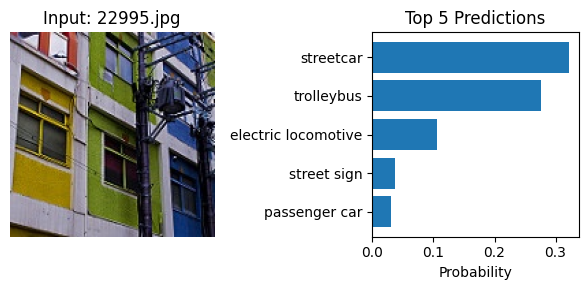

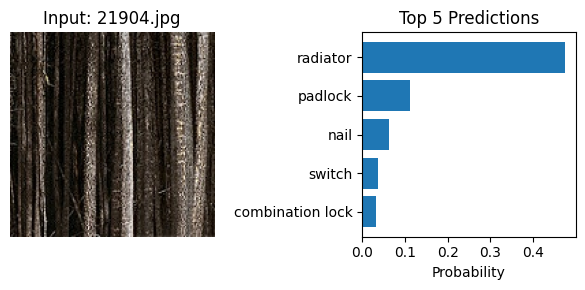

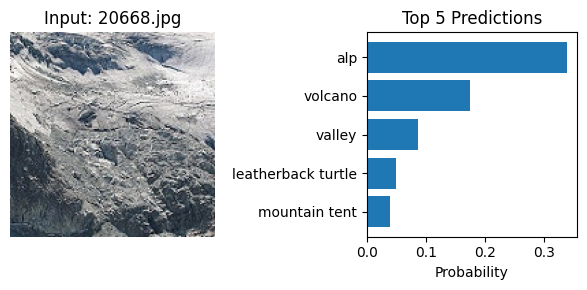

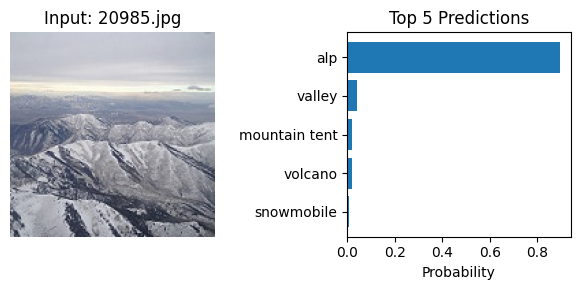

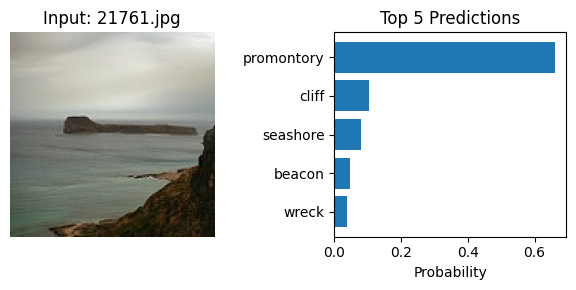

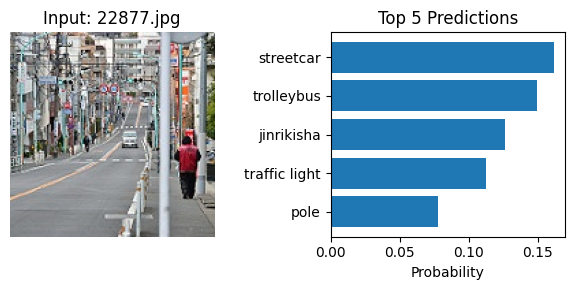

In [19]:
#Q4

for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

    labels = [name for name, prob in preds]   # the 5 class names
    probs  = [prob for name, prob in preds]   # the 5 probabilities

    plt.figure(figsize=(6, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Input: {img_name}")

    plt.subplot(1, 2, 2)
    plt.barh(labels[::-1], probs[::-1])
    plt.xlabel("Probability")
    plt.title("Top 5 Predictions")

    plt.tight_layout()
    plt.savefig("outputs/warmup_inference_viz.png")
    plt.show()